# Peer agreement vs paid AI judges on held-out NL→FOL (T1 head-on test): demo

**Setting.** You have a natural-language sentence and a candidate first-order-logic (FOL) formula from some NL→FOL
system, and **no gold formula**. Does the candidate say what the sentence says?

**What the artifact did.** On a held-out meta-evaluation set E (8,507 real candidates from 13 system×prompt variants,
700 sentences, labelled via prover-checked equivalence to gold plus a panel), it compared the frozen **peer-agreement
consensus metric** `c_score_align` against the judges a practitioner would actually pay for:

| metric | what it is |
|---|---|
| `c_score_align` | frozen consensus: disagreement of the candidate with the *other systems'* formalisations of the same sentence (z3 equivalence modulo aligned vocabulary) |
| `p_peer_text` | frozen PEER+TEXT fusion (consensus + text-side features) |
| `judge_cheap_disg/orig` | gemini-2.5-flash-lite, rubric-A JSON judge, nonce-**disg**uised or **orig**inal view (the pre-registered primary bar is `judge_cheap_disg`) |
| `judge_cheap2_disg/orig` | gpt-4.1-nano P(YES) judge |
| `judge_strong_orig` | gemini-3.1-pro-preview frontier judge (284-row frame only) |
| `rt_nli_min` | API round trip: FOL→English (flash-lite) → DeBERTa NLI against the sentence |
| `sc5_eq_frac` | API SC-5 self-consistency: nano resamples (T=0.7), z3 equivalence modulo vocabulary |
| `S4_full_oof` | cross-fitted logistic stack of **all 28 baselines** (out-of-fold) |

Every score is **oriented: higher = more likely unfaithful (ERROR)**.

**What this notebook runs.** `method.py` is a stage orchestrator; most stages call paid APIs, GPU models or z3 over
thousands of rows. Their outputs are the `predict_*` columns of `full_method_out.json`. This notebook keeps the
**final analysis stage** (`method.py --stage t1_analysis`, i.e. `src/analyse_T1.py` + the statistics core of
`src/api_bar.py`), which is where the scores meet the labels and every pre-registered criterion is decided. The code
is copied as-is and runs on a curated 100-row subset (25 rows per source stratum). Only the parts that read
server files or need re-scoring are adapted.

Pre-registered criteria tested here: **(a)** consensus beats the cheap API judge, **(b)** it adds signal over the stack of
all baselines, **(d)** it approaches the frontier judge at ≤10% of its cost, **VEX** (an aligner-confound control), and
**M3** (a smaller length slope than the judge). Also descriptive: complexity curves, system-level τ, and a placebo.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original analysis logs through it)
_pip('loguru==0.7.3')

# numpy, scipy, pandas, scikit-learn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original import blocks of `method.py`, `src/api_bar.py` and `src/analyse_T1.py`. The project-internal import
(`from src.common import ...`) is dropped because the notebook is self-contained. `matplotlib`/`pandas` are added for
the final results cell.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import os
import sys
import time
import types
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Callable, Sequence

import numpy as np
from scipy.stats import rankdata
from loguru import logger

import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("PYTHONHASHSEED", "0")
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# GEE fits on ~100 rows emit many convergence / domain warnings; they are handled by the pre-declared GLM fallback
warnings.filterwarnings("ignore")

## Data loading
`mini_demo_data.json` has the same format as the artifact's `full_method_out.json`, with one example per
(sentence, candidate FOL, system) row:
- `input`: sentence, candidate FOL, system, prompt variant;
- `output`: the dataset-E final label (`ERROR` / `CORRECT`);
- `predict_*`: every metric's oriented score;
- `metadata_*`: sentence id, source stratum, complexity strata, label tier, regime membership, VEX flag.

The file's `metadata` also carries the full-scale reference numbers (n = 2,686) and the pre-registered thresholds.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
META = data["metadata"]
REF = META["full_scale_reference"]
print(f"{len(examples)} rows | labels {dict(Counter(e['output'] for e in examples))} | "
      f"strata {dict(Counter(e['metadata_strata']['source_stratum'] for e in examples))}")
print(json.dumps(json.loads(examples[0]["input"]), ensure_ascii=False, indent=1))

100 rows | labels {'CORRECT': 51, 'ERROR': 49} | strata {'L25': 25, 'L20': 25, 'EXC': 25, 'CTRL': 25}
{
 "text": "A plant is characterized as a succulent when it stores water in its leaves, stems, or roots, thrives in arid conditions, and exhibits a fleshy appearance.",
 "candidate_fol": "∀x (Plant(x) → (CharacterizedAs(x, succulent) ↔ (StoresWaterIn(x, leaves) ∨ StoresWaterIn(x, stems) ∨ StoresWaterIn(x, roots)) ∧ ThrivesIn(x, aridConditions) ∧ Exhibits(x, fleshyAppearance)))",
 "system": "G4:deepseek/deepseek-v3.2",
 "prompt_variant": "fewshot_v1"
}


## Configuration
All tunable parameters, with the original values in the comments. On 100 rows the notebook runs every bootstrap at
its original size: B = 2000, 1000 for the complexity bins and system level, and 200 placebo reps. The whole
analysis takes about 1–2 minutes. The one reduced value is the M3 GEE bootstrap: 100 reps instead of 1000, because
each rep refits two GEE models. Set `GEE_B = 1000` to match the original, which adds a few minutes.

In [5]:
B = 2000  # sentence-cluster bootstrap reps for every AUROC / delta CI            (original: 2000)
COMPLEXITY_B = 1000  # bootstrap reps inside the complexity bins                 (original: 1000)
SYSTEM_B = 1000  # bootstrap reps for system-level Kendall tau                       (original: 1000)
GEE_B = 100  # M3: cluster-bootstrap reps of the GEE slope difference                  (original: 1000)
GEE_PROBE_B = 20  # M3: timing-probe reps used to choose the bootstrap size       (original: 20)
T_BUDGET_GEE_S = 120.0  # M3: time budget for the GEE bootstrap before falling back to 500 (original: 2400)
N_PLACEBO = 200  # shuffled-label placebo reps                                (original: 200)
N_JOBS = 2          # joblib workers for the GEE bootstrap                                 (original: 7)

## 1. Statistics core (`src/api_bar.py`)
These are copied as-is from the artifact. Everything is sentence-clustered, because each sentence contributes
several candidates:
- `auroc`: Mann–Whitney AUROC, with ties counted as ½.
- `strat_auroc`: **within-stratum AUROC**. Only ERROR/CORRECT pairs from the same source stratum (L25, L20, EXC, CTRL)
  are counted. This removes the part of pooled AUROC that comes from stratum composition, and it is the
  pre-registered primary statistic.
- `ClusterBoot`: resamples sentences with replacement. Every metric on a row set uses the **same** resamples, so deltas
  are paired.
- `paired_boot`, `delong`, `matched_fa_threshold`/`recall_at`, `ipw_auroc`, `nested_delta`, `gee_slope(_diff)`.

The async API metric wrappers (`judge_api`, `judge_pyes`, `frontier_judge`, `sc5_api`, `roundtrip_api`) need an
OpenRouter key and the budget-guarded client. They are not re-run here; their outputs are the `predict_judge_*`,
`predict_sc5_*` and `predict_rt_*` columns. `build_s4` and `permutation_null` refit stacks on 28 raw features that
`full_method_out.json` does not carry, so the stacks enter as their saved out-of-fold predictions (`S4_*_oof`).

In [6]:
STRATA = ("L25", "L20", "EXC", "CTRL")


# ===================================================================================================== statistics
def auroc(y, s) -> float:
    '''Mann-Whitney AUROC, ties counted 1/2 (== sklearn roc_auc_score). nan if one class is empty.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def tie_rate(y, s) -> float:
    '''Share of (ERROR, CORRECT) pairs whose scores are exactly tied.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    vals, inv = np.unique(np.concatenate([pos, neg]), return_inverse=True)
    cp = np.bincount(inv[:len(pos)], minlength=len(vals))
    cn = np.bincount(inv[len(pos):], minlength=len(vals))
    return float((cp * cn).sum() / (len(pos) * len(neg)))


def strat_auroc(y, s, stratum) -> float:
    '''Within-stratum AUROC: sum_h AUC_h * P_h * N_h / sum_h P_h * N_h (only (ERROR, CORRECT) pairs from the same
    source stratum count), identical to exp 5's strat_auc. Removes the stratum-composition part of pooled AUROC.'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    stratum = np.asarray(stratum)
    num = den = 0.0
    for h in np.unique(stratum):
        m = stratum == h
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auroc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    '''Sentence-clustered bootstrap index sets: resample sentence ids with replacement (fixed seed); every metric on a
    row set uses the IDENTICAL resamples, which makes deltas paired.'''

    def __init__(self, clusters: Sequence[str], b: int = 2000, seed: int = 0):
        by = defaultdict(list)
        for i, c in enumerate(clusters):
            by[c].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = []
        for _ in range(b):
            pick = rng.integers(0, len(keys), len(keys))
            self.idx.append(np.concatenate([arr[j] for j in pick]))
        self.n_clusters = len(keys)


def boot_ci(vals, lo: float = 2.5, hi: float = 97.5) -> list:
    v = np.asarray([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def paired_boot(y, a, c, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    '''Paired delta stat(a) - stat(c) on identical rows; percentile CI over cluster resamples; one-sided
    p = share of resampled deltas <= 0. stat in {'pooled', 'strat'} (strat needs `stratum`).'''
    y = np.asarray(y)
    a = np.asarray(a, float)
    c = np.asarray(c, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pa, pc = f(y, a, st), f(y, c, st)
    da, dc, dd = [], [], []
    for ix in cb.idx:
        hh = None if st is None else st[ix]
        xa, xc = f(y[ix], a[ix], hh), f(y[ix], c[ix], hh)
        da.append(xa)
        dc.append(xc)
        dd.append(xa - xc)
    dd_ = np.array([d for d in dd if not math.isnan(d)])
    return {"a": pa, "b": pc, "a_ci": boot_ci(da), "b_ci": boot_ci(dc), "delta": pa - pc, "ci": boot_ci(dd),
            "p_one_sided_le0": float(np.mean(dd_ <= 0)) if len(dd_) else None, "se": float(np.std(dd_)) if len(dd_) else None,
            "n": int(len(y)), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "stat": stat}


def boot_stat(y, s, cb: ClusterBoot, stat: str = "pooled", stratum=None) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    st = None if stratum is None else np.asarray(stratum)
    f = (lambda yy, ss, hh: auroc(yy, ss)) if stat == "pooled" else strat_auroc
    pt = f(y, s, st)
    bs = [f(y[ix], s[ix], None if st is None else st[ix]) for ix in cb.idx]
    return {"auroc": pt, "ci": boot_ci(bs)}


def delong(y, s1, s2) -> dict:
    '''DeLong paired test on pooled AUROC (secondary: ignores sentence clustering).'''
    from scipy.stats import norm
    y = np.asarray(y)
    s1 = np.asarray(s1, float)
    s2 = np.asarray(s2, float)
    pos, neg = s1[y == 1], s1[y == 0]
    pos2, neg2 = s2[y == 1], s2[y == 0]
    m, n = len(pos), len(neg)
    if m < 2 or n < 2:
        return {"z": None, "p": None}

    def comps(p, q):
        # V10_i = mean_j [p_i > q_j] + .5[p_i == q_j]; vectorised by ranks
        allv = np.concatenate([p, q])
        r_all = rankdata(allv)
        r_p = rankdata(p)
        r_q = rankdata(q)
        v10 = (r_all[:len(p)] - r_p) / len(q)
        v01 = 1.0 - (r_all[len(p):] - r_q) / len(p)
        return v10, v01
    a10, a01 = comps(pos, neg)
    b10, b01 = comps(pos2, neg2)
    d = a10.mean() - b10.mean()
    s10 = np.cov(np.vstack([a10, b10]))
    s01 = np.cov(np.vstack([a01, b01]))
    var = (s10[0, 0] + s10[1, 1] - 2 * s10[0, 1]) / m + (s01[0, 0] + s01[1, 1] - 2 * s01[0, 1]) / n
    if var <= 0:
        return {"z": None, "p": None}
    z = d / math.sqrt(var)
    return {"z": float(z), "p": float(2 * (1 - norm.cdf(abs(z))))}


def matched_fa_threshold(neg_vals, fa: float = 0.10) -> float:
    '''Threshold t = the (1-fa) quantile of the scores of CORRECT rows (flag = score > t).'''
    return float(np.quantile(np.asarray(neg_vals, float), 1 - fa))


def recall_at(y, s, t) -> dict:
    y = np.asarray(y)
    s = np.asarray(s, float)
    f = s > t
    tp = int((f & (y == 1)).sum())
    fp = int((f & (y == 0)).sum())
    return {"threshold": float(t), "recall": tp / max(1, int(y.sum())), "fa": fp / max(1, int((y == 0).sum())),
            "precision": tp / max(1, tp + fp), "n_flag": int(f.sum())}


def ipw_auroc(y, s, w) -> float:
    '''Weighted Mann-Whitney AUROC: each (ERROR i, CORRECT j) pair weighted w_i * w_j (w = 1 / inclusion prob).'''
    y = np.asarray(y)
    s = np.asarray(s, float)
    w = np.asarray(w, float)
    p, n = s[y == 1], s[y == 0]
    wp, wn = w[y == 1], w[y == 0]
    if len(p) == 0 or len(n) == 0:
        return float("nan")
    gt = (p[:, None] > n[None, :]) + 0.5 * (p[:, None] == n[None, :])
    ww = wp[:, None] * wn[None, :]
    return float((gt * ww).sum() / ww.sum())


# ===================================================================================================== stacks
def nested_delta(y, s_big, s_small, cb: ClusterBoot, stratum=None) -> dict:
    '''OOF(S+X) - OOF(S) on identical rows; pooled and stratified, paired cluster bootstrap over OOF predictions
    (no refit inside the bootstrap: exp D / exp 6 convention; slightly understates variance).'''
    return {"pooled": paired_boot(y, s_big, s_small, cb, "pooled"),
            "strat": paired_boot(y, s_big, s_small, cb, "strat", stratum) if stratum is not None else None}


# ===================================================================================================== GEE
def gee_slope(correct, z, stratum, groups, alt_glm: bool = True) -> dict:
    '''GEE Binomial(logit), exchangeable, clustered by sentence: correct ~ z + C(stratum). Returns slope of z.'''
    import pandas as pd
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    df = pd.DataFrame({"c": np.asarray(correct, float), "z": np.asarray(z, float), "h": np.asarray(stratum), "g": np.asarray(groups)})
    try:
        m = smf.gee("c ~ z + C(h)", groups="g", data=df, family=sm.families.Binomial(),
                    cov_struct=sm.cov_struct.Exchangeable()).fit()
        ci_ = m.conf_int().loc["z"].tolist()
        return {"slope": float(m.params["z"]), "ci_model": [float(ci_[0]), float(ci_[1])], "p": float(m.pvalues["z"]),
                "fit": "GEE_exchangeable"}
    except Exception as e:  # noqa: BLE001 - non-convergence -> cluster-robust GLM (pre-declared fallback)
        if not alt_glm:
            raise
        m = smf.glm("c ~ z + C(h)", data=df, family=sm.families.Binomial()).fit(cov_type="cluster",
                                                                               cov_kwds={"groups": pd.factorize(df["g"])[0]})
        ci_ = m.conf_int().loc["z"].tolist()
        return {"slope": float(m.params["z"]), "ci_model": [float(ci_[0]), float(ci_[1])], "p": float(m.pvalues["z"]),
                "fit": f"GLM_cluster_fallback ({str(e)[:60]})"}


def _gee_fast_slope(c, z, H, g) -> float:
    '''Slope from a GEE fit (used inside the bootstrap).'''
    try:
        return gee_slope(c, z, H, g)["slope"]
    except Exception:  # noqa: BLE001
        return float("nan")


def gee_slope_diff(correct_a, correct_b, z, stratum, groups, B: int = 1000, seed: int = 0, n_jobs: int = 7) -> dict:
    '''M3 statistic: slope_a - slope_b (log-odds of a correct flag per SD of z), cluster bootstrap over sentences
    (resampled sentences get fresh cluster ids so duplicates are separate clusters).'''
    from joblib import Parallel, delayed
    ca, cb_, z, H, g = (np.asarray(x) for x in (correct_a, correct_b, z, stratum, groups))
    sa, sb = gee_slope(ca, z, H, g), gee_slope(cb_, z, H, g)
    # fresh cluster ids per draw: the position of the cluster in the draw
    by = defaultdict(list)
    for i, s in enumerate(g):
        by[s].append(i)
    keys = sorted(by)
    arr = [np.array(by[k]) for k in keys]
    rng = np.random.default_rng(seed)
    draws = [rng.integers(0, len(keys), len(keys)) for _ in range(B)]

    def rep(pick):
        ix = np.concatenate([arr[j] for j in pick])
        gid = np.concatenate([np.full(len(arr[j]), n) for n, j in enumerate(pick)])
        return (_gee_fast_slope(ca[ix], z[ix], H[ix], gid), _gee_fast_slope(cb_[ix], z[ix], H[ix], gid))
    res = Parallel(n_jobs=n_jobs)(delayed(rep)(p) for p in draws)
    d = [x - y for x, y in res if not (math.isnan(x) or math.isnan(y))]
    return {"slope_a": sa, "slope_b": sb, "diff": sa["slope"] - sb["slope"], "ci": boot_ci(d), "B_ok": len(d), "B": B,
            "slope_a_ci_boot": boot_ci([x for x, _ in res]), "slope_b_ci_boot": boot_ci([y for _, y in res])}


# the analysis below calls these as AB.<name> (module alias of src/api_bar.py in the original)
AB = types.SimpleNamespace(auroc=auroc, tie_rate=tie_rate, strat_auroc=strat_auroc, ClusterBoot=ClusterBoot, boot_ci=boot_ci,
                           paired_boot=paired_boot, boot_stat=boot_stat, delong=delong, matched_fa_threshold=matched_fa_threshold,
                           recall_at=recall_at, ipw_auroc=ipw_auroc, nested_delta=nested_delta, gee_slope=gee_slope,
                           gee_slope_diff=gee_slope_diff)

## 2. Analysis scaffolding: `Table` and `Cell` (`src/analyse_T1.py`)
- `Table` looks up the oriented value of any metric for any row. It reads API columns (with status), `L:`-prefixed
  local baselines, stacked `extra` columns and plain row fields.
- `Cell` is a labelled row set (keys, labels, sentence clusters, strata) with **one bootstrap shared by every
  metric** in the cell. That sharing makes every `delta(a, b)` a paired comparison on identical rows.
- `describe` gives the per-metric summary: AUROC, AUPRC, tie rate, and recall at a matched false-alarm rate of 0.10.
  It uses a label-free, seeded tie-breaker, because quantised judge scores put more than 10% of CORRECT rows at the
  maximum (deviation D5).

The code below is copied as-is, apart from the constant `B`, which now comes from the config cell.

In [7]:
STRATA = ["L25", "L20", "EXC", "CTRL"]
LONG = ("L25", "L20", "EXC")
CHALLENGERS = ["c_score_align", "g_score", "nf_c_score", "p_peer_text", "p_text"]
API_BARS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig"]
LOCAL_BAR = "L:judge_local_qwen8b_disg"
# B = 2000  -> set in the config cell
TIEBREAK_EPS = 1e-9


def _u01(k: str) -> float:
    return int(hashlib.sha1(("tiebreak|" + k).encode()).hexdigest()[:12], 16) / 16 ** 12


# ===================================================================================================== table
class Table:
    '''Per-row values of every metric (oriented), with the status-aware accessor .vec(metric, keys).'''

    def __init__(self, rows, api, fail_fill):
        self.rows = rows
        self.by = {x["canonical_key"]: x for x in rows}
        self.api = api
        self.fail_fill = fail_fill
        self.extra: dict[str, dict] = {}

    def value(self, m: str, k: str):
        if m in self.extra:
            return self.extra[m].get(k)
        if m in self.api:
            return self.api[m]["v"].get(k)
        x = self.by[k]
        if m.startswith("L:"):
            st = x.get(m + "__status")
            v = x.get(m)
            if st == "fail":
                return self.fail_fill.get(m[2:], 1.0) if v is None else v
            return v
        return x.get(m)

    def status(self, m: str, k: str) -> str:
        if m in self.api:
            return self.api[m]["st"].get(k, "missing")
        if m.startswith("L:"):
            return self.by[k].get(m + "__status") or "na"
        return "ok" if self.value(m, k) is not None else "missing"

    def vec(self, m: str, keys) -> np.ndarray:
        return np.array([np.nan if (v := self.value(m, k)) is None else float(v) for k in keys], float)

    def vec_tb(self, m: str, keys) -> np.ndarray:
        '''vec() + a label-free, seeded tie-breaker (TIEBREAK_EPS x U[0,1) from sha1(canonical_key)) for the matched-FA
        operating points: quantised scores put >10% of CORRECT rows at the maximum, so 'flag = s > q90' never fires
        without it (randomised test; AUROCs never use it).'''
        return self.vec(m, keys) + TIEBREAK_EPS * np.array([_u01(k) for k in keys])

    def has(self, m: str) -> bool:
        return m in self.extra or m in self.api or any(self.value(m, x["canonical_key"]) is not None for x in self.rows[:500])


class Cell:
    '''A labelled row set (keys, y, clusters, strata) with one bootstrap shared by every metric of the cell.'''

    def __init__(self, name, keys, y, T: Table, b=None):
        b = B if b is None else b  # original default: b=B (module constant 2000)
        self.name, self.keys, self.y = name, list(keys), np.asarray(y)
        self.cl = np.array([T.by[k]["sentence_id"] for k in self.keys])
        self.h = np.array([T.by[k]["source_stratum"] for k in self.keys])
        self.T = T
        self.b = b
        self._boots: dict = {}
        self._cache: dict = {}

    def boot(self, mask):
        key = hashlib.sha1(mask.tobytes()).hexdigest()
        if key not in self._boots:
            self._boots[key] = AB.ClusterBoot(list(self.cl[mask]), b=self.b, seed=0)
        return key, self._boots[key]

    def series(self, m, mask, stat):
        mk, cb = self.boot(mask)
        ck = (mk, m, stat)
        if ck not in self._cache:
            s = self.T.vec(m, self.keys)[mask]
            y, h = self.y[mask], self.h[mask]
            f = (lambda yy, ss, hh: AB.auroc(yy, ss)) if stat == "pooled" else AB.strat_auroc
            pt = f(y, s, h)
            bs = np.array([f(y[ix], s[ix], h[ix]) for ix in cb.idx])
            self._cache[ck] = (pt, bs)
        return self._cache[ck]

    def mask_for(self, *ms):
        mask = np.ones(len(self.keys), bool)
        for m in ms:
            mask &= ~np.isnan(self.T.vec(m, self.keys))
        return mask

    def n_info(self, mask):
        y = self.y[mask]
        return {"n": int(mask.sum()), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()),
                "n_sentences": int(len(set(self.cl[mask])))}

    def metric(self, m, stat="pooled", mask=None):
        mask = self.mask_for(m) if mask is None else mask
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pt, bs = self.series(m, mask, stat)
        return {"auroc": pt, "ci": AB.boot_ci(bs), **self.n_info(mask)}

    def delta(self, a, c, stat="strat"):
        mask = self.mask_for(a, c)
        if mask.sum() < 10 or len(set(self.y[mask])) < 2:
            return {"untestable": True, **self.n_info(mask)}
        pa, ba = self.series(a, mask, stat)
        pc, bc = self.series(c, mask, stat)
        d = ba - bc
        d = d[~np.isnan(d)]
        out = {"a": a, "b": c, "stat": stat, "auroc_a": pa, "auroc_b": pc, "delta": pa - pc, "ci": AB.boot_ci(d),
               "p_one_sided_le0": float(np.mean(d <= 0)) if len(d) else None, "se": float(np.std(d)) if len(d) else None,
               **self.n_info(mask)}
        if stat == "pooled" and mask.sum() <= 6000:
            y = self.y[mask]
            dl = AB.delong(y, self.T.vec(a, self.keys)[mask], self.T.vec(c, self.keys)[mask])
            out["delong_z"], out["delong_p"] = dl["z"], dl["p"]
        return out


def testable(y, cl) -> bool:
    y = np.asarray(y)
    cl = np.asarray(cl)
    return int(y.sum()) >= 50 and int((y == 0).sum()) >= 50 and len(set(cl[y == 1])) >= 25 and len(set(cl[y == 0])) >= 25


# ===================================================================================================== descriptive per metric
def describe(cell: Cell, m: str, thr: dict, cost_item: dict) -> dict:
    mask = cell.mask_for(m)
    y = cell.y[mask]
    s = cell.T.vec(m, cell.keys)[mask]
    from sklearn.metrics import average_precision_score
    out = cell.metric(m, "pooled", mask)
    if out.get("untestable"):
        return out
    out["strat"] = cell.metric(m, "strat", mask)
    out["auprc"] = float(average_precision_score(y, s))
    out["prevalence"] = float(y.mean())
    out["tie_rate"] = AB.tie_rate(y, s)
    if m in thr and thr[m] is not None:
        out["at_frozen_threshold"] = AB.recall_at(y, s, thr[m])
    stb = cell.T.vec_tb(m, cell.keys)[mask]
    out["at_FA0.10_E"] = AB.recall_at(y, stb, AB.matched_fa_threshold(stb[y == 0], 0.10))
    out["at_FA0.10_E"]["share_correct_at_max"] = float(np.mean(s[y == 0] == np.max(s)))
    out["usd_per_item"] = cost_item.get(m)
    st = Counter(cell.T.status(m, k) for k in cell.keys)
    out["status_counts"] = dict(st)
    return out

## 3. Join: rows, label regimes, API columns
In the artifact, `run()` builds these objects from several sources:
- dataset E's files (`e_pool.load_E`, `regime_labels`);
- the canonical key map (`join_T1.base_rows`);
- the raw API score files (`join_T1.api_columns`).

`full_method_out.json` (and so `mini_demo_data.json`) is the artifact's own flat export of the same join. This cell
therefore rebuilds `rows`, `regimes` and `api` from it:
- Label regime **R_AB** is tier-A and tier-B labelled rows; **R_A** is tier-A only. The label is `1 = ERROR`,
  `0 = CORRECT`.
- API columns get status `ok` or `missing`, where `NA` means not scored.
- `predict_local_*` become the `L:`-prefixed local baselines.
- The saved out-of-fold stack predictions `S4_*_oof` go into `T.extra`, exactly where `s4_nesting()` puts its refits.
- `pre` holds the pre-registered thresholds from `prereg_T1.json`, which are shipped in the data file's metadata.

In [8]:
API_COLS = ["judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig", "judge_strong_orig",
            "judge_strong_disg", "judge_cheap_disg_vfb", "rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra",
            "rt_nli_min_alt", "rt_embed_cos", "sc5_eq_frac", "sc5_entropy"]
OOF_COLS = ["S4_full_oof", "S4_local_oof", "S4_full_plus_c_score_align_oof", "PT_refit_oof", "PT_refit_NF_oof"]


def _f(v):
    return None if v == "NA" else float(v)


rows, oof = [], {c: {} for c in OOF_COLS}
api = {c: {"v": {}, "st": {}} for c in API_COLS}
regimes = {"R_AB": {}, "R_A": {}}
for e in examples:
    inp = json.loads(e["input"])
    k = e["metadata_canonical_key"]
    x = {"canonical_key": k, "exp6_row_key": e["metadata_exp6_row_key"], "item_id": e["metadata_item_id"],
         "sentence_id": e["metadata_sentence_id"], "fold_E": e["metadata_fold_E"], "pool": e["metadata_pool"],
         "parse_ok": e["metadata_parse_ok"], "sysvar": e["metadata_sysvar"], "family": e["metadata_family"],
         "strata": e["metadata_strata"], "source_stratum": e["metadata_strata"]["source_stratum"],
         "label_tier": e["metadata_label_tier"], "vex": e["metadata_vex"], "final_label": e["output"], **inp}
    for col, v in e.items():
        if not col.startswith("predict_"):
            continue
        m = col[len("predict_"):]
        if m in API_COLS:
            if v != "NA":
                api[m]["v"][k] = _f(v)
                api[m]["st"][k] = "ok"
        elif m in OOF_COLS:
            oof[m][k] = _f(v)
        elif m.startswith("local_"):
            x["L:" + m[len("local_"):]] = _f(v)
            x["L:" + m[len("local_"):] + "__status"] = "na" if v == "NA" else "ok"
        else:
            x[m] = _f(v)
    rows.append(x)
    if e["metadata_in_R_AB"] and e["output"] in ("ERROR", "CORRECT"):
        regimes["R_AB"][k] = int(e["output"] == "ERROR")
    if e["metadata_in_R_A"] and e["output"] in ("ERROR", "CORRECT"):
        regimes["R_A"][k] = int(e["output"] == "ERROR")
api = {c: v for c, v in api.items() if v["v"]}  # drop columns that no demo row carries (e.g. the frontier disguised view)
pre = {"thresholds": META["prereg_thresholds"]}
fail_fill = {c: math.log(6) if c.endswith("entropy") else 1.0 for c in api}
T = Table(rows, api, fail_fill)
for c, v in oof.items():
    T.extra[c] = v
A: dict = {"api_columns": sorted(api)}
print(f"rows {len(rows)} | R_AB {len(regimes['R_AB'])} | R_A {len(regimes['R_A'])} | API columns {sorted(api)}")

rows 100 | R_AB 100 | R_A 32 | API columns ['judge_cheap2_disg', 'judge_cheap2_orig', 'judge_cheap_disg', 'judge_cheap_disg_vfb', 'judge_cheap_orig', 'judge_strong_orig', 'rt_embed_cos', 'rt_nli_bwd', 'rt_nli_contra', 'rt_nli_fwd', 'rt_nli_min', 'rt_nli_min_alt', 'sc5_entropy', 'sc5_eq_frac']


## 4. Population, API coverage, cost and the head-on criterion (a)
This is the first half of `analyse_T1.run()`, copied as-is:
- `keys_for(regime, pool, primary, strata)` selects labelled rows: E_POOL, parseable (PRIMARY), optionally
  restricted to some source strata.
- The **cells** are R_AB pooled, the long pool (L25+L20+EXC), each stratum, R_A L20+EXC, and R_A L20+EXC+CTRL.
  Cells for regimes that `full_method_out.json` does not export (COVERAGE, CONTESTED_*, ALL_TIERS) are skipped,
  via the `if r in regimes` guard.
- For every cell: each challenger's and each bar's AUROC (strat + pooled), and every paired delta challenger − bar.
- **Criterion (a)** is an intersection–union test against the primary bar `judge_cheap_disg`. All three parts must
  hold: the R_AB strat CI is above 0, the long-pool strat CI is above 0, and the R_A L20+EXC Δ is above 0.

Per-item costs cannot be recomputed from 100 rows (they need the `costs.jsonl` call ledger), so they are taken from
the full run's metadata.

In [9]:
t0 = time.time()
# ---------------------------------------------------------------- populations
def keys_for(regime, pool="E_POOL", primary=True, strata=None, extra=None):
    lab = regimes[regime]
    ks = [x["canonical_key"] for x in rows if x["canonical_key"] in lab and x["pool"] == pool
          and (x["parse_ok"] or not primary) and (strata is None or x["source_stratum"] in strata)
          and (extra is None or extra(x))]
    return ks, np.array([lab[k] for k in ks])
P, yP = keys_for("R_AB")
A["population"] = {"n": len(P), "n_error": int(yP.sum()), "n_correct": int(len(yP) - yP.sum()),
                   "n_sentences": len({T.by[k]["sentence_id"] for k in P})}
logger.info(f"population {A['population']}")
# ---------------------------------------------------------------- API coverage + status
cov = {}
for c in api:
    st = Counter(api[c]["st"].get(k, "missing") for k in P)
    cov[c] = {"status_RAB_primary": dict(st), "coverage_RAB": (st["ok"] + st["fallback"]) / max(1, len(P)),
              "status_all_rows": dict(Counter(api[c]["st"].values()))}
A["api_coverage"] = cov
# ---------------------------------------------------------------- cost per item (from the full run: needs the call ledger)
cost_item = dict(REF["per_item_usd"])
cons_cost = REF["consensus_cost"]
A["cost"] = {"per_item_usd": cost_item, "consensus": cons_cost}
# ---------------------------------------------------------------- bars
bars = [b for b in API_BARS if b in api]
api_bar_ok = "judge_cheap_disg" in api and cov["judge_cheap_disg"]["coverage_RAB"] >= 0.95
A["bar"] = {"primary": "judge_cheap_disg", "available": api_bar_ok, "api_bars_present": bars,
            "coverage": {b: cov[b]["coverage_RAB"] for b in bars}}
cellP = Cell("R_AB pooled", P, yP, T)
pooled_bar = {b: cellP.metric(b, "pooled")["auroc"] for b in bars if not cellP.metric(b, "pooled").get("untestable")}
best = max(pooled_bar, key=pooled_bar.get) if pooled_bar else None
A["bar"]["BEST_API_CHEAP"] = best
A["bar"]["pooled_auroc"] = pooled_bar
bar_list = bars + [LOCAL_BAR]
# ---------------------------------------------------------------- (a) head-on bar
cells = {}
cells["R_AB pooled"] = cellP
k, y = keys_for("R_AB", strata=LONG)
cells["R_AB long (L25+L20+EXC)"] = Cell("R_AB long", k, y, T)
for h in STRATA:
    k, y = keys_for("R_AB", strata=(h,))
    cells[f"R_AB {h}"] = Cell(f"R_AB {h}", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC"))
cells["R_A L20+EXC"] = Cell("R_A L20+EXC", k, y, T)
k, y = keys_for("R_A", strata=("L20", "EXC", "CTRL"))
cells["R_A L20+EXC+CTRL"] = Cell("R_A L20+EXC+CTRL", k, y, T)
if "COVERAGE" in regimes:  # not exported in method_out (needs the unparseable rows' regime labels)
    k, y = keys_for("COVERAGE", primary=False)
    cells["COVERAGE (unparseable = ERROR)"] = Cell("COVERAGE", k, y, T)
for r in ("CONTESTED_AS_CORRECT", "CONTESTED_AS_ERROR", "ALL_TIERS", "R_AB_L25_NO_TOPUP"):
    if r in regimes:
        k, y = keys_for(r)
        cells[r] = Cell(r, k, y, T, b=1000)
A["a_head_on"] = {}
for cname, cell in cells.items():
    out = {"n": len(cell.keys), "n_error": int(cell.y.sum()), "n_correct": int(len(cell.y) - cell.y.sum()),
           "n_sentences": len(set(cell.cl)), "testable": testable(cell.y, cell.cl), "deltas": {}, "metrics": {}}
    stats = ["strat", "pooled"] if cname not in [f"R_AB {h}" for h in STRATA] else ["pooled"]
    for m in CHALLENGERS + bar_list + ["peer_only"]:
        out["metrics"][m] = {st: cell.metric(m, st) for st in stats}
    for a in CHALLENGERS:
        for bb in bar_list:
            for st in stats:
                out["deltas"][f"{a} - {bb} [{st}]"] = cell.delta(a, bb, st)
    A["a_head_on"][cname] = out
    logger.info(f"(a) {cname}: n={out['n']} " + ", ".join(
        f"{a}-cheap_disg[{stats[0]}]={out['deltas'].get(f'{a} - judge_cheap_disg [{stats[0]}]', {}).get('delta', float('nan')):.3f}"
        for a in ("c_score_align", "p_peer_text")))
# per-metric description on the main population
thr = {"judge_cheap_disg": 0.5, "judge_cheap_orig": 0.5, "judge_cheap2_disg": 0.5, "judge_cheap2_orig": 0.5,
       "judge_strong_orig": 0.5, "judge_strong_disg": 0.5, "p_peer_text": pre["thresholds"]["consensus_PT"]["fused"],
       "p_text": pre["thresholds"]["consensus_PT"]["text"], LOCAL_BAR: 0.5}
# ---------------------------------------------------------------- criterion (a)
def crit_a(bar):
    c1 = A["a_head_on"]["R_AB pooled"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c2 = A["a_head_on"]["R_AB long (L25+L20+EXC)"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    c3 = A["a_head_on"]["R_A L20+EXC"]["deltas"].get(f"c_score_align - {bar} [strat]", {})
    ok1 = bool(c1.get("ci") and c1["ci"][0] is not None and c1["ci"][0] > 0)
    ok2 = bool(c2.get("ci") and c2["ci"][0] is not None and c2["ci"][0] > 0)
    ok3 = bool(c3.get("delta") is not None and c3["delta"] > 0)
    return {"bar": bar, "R_AB_strat": {k_: c1.get(k_) for k_ in ("delta", "ci", "n", "p_one_sided_le0")}, "R_AB_strat_CI_gt0": ok1,
            "long_strat": {k_: c2.get(k_) for k_ in ("delta", "ci", "n")}, "long_strat_CI_gt0": ok2,
            "R_A_L20EXC": {k_: c3.get(k_) for k_ in ("delta", "ci", "n")}, "R_A_sign_gt0": ok3, "holds": ok1 and ok2 and ok3}
A["criterion_a"] = {b: crit_a(b) for b in bar_list}
# sensitivity: JSON-failure verdict fallback (prereg_T1.judge_json_failure_sensitivity)
for vb in ("judge_cheap_disg_vfb", "judge_cheap_orig_vfb"):
    if vb in api:
        for cname in ("R_AB pooled", "R_AB long (L25+L20+EXC)", "R_A L20+EXC"):
            for a in ("c_score_align", "p_peer_text"):
                A["a_head_on"][cname]["deltas"][f"{a} - {vb} [strat]"] = cells[cname].delta(a, vb, "strat")
        A["criterion_a"][vb] = crit_a(vb)
        A["a_head_on"]["R_AB pooled"]["metrics"][vb] = {"strat": cellP.metric(vb, "strat"), "pooled": cellP.metric(vb, "pooled")}
print(f"(a) done in {time.time()-t0:.1f}s")
print(json.dumps(A["criterion_a"]["judge_cheap_disg"], indent=1, default=float))

11:37:44|INFO   |population {'n': 100, 'n_error': 49, 'n_correct': 51, 'n_sentences': 36}


11:37:48|INFO   |(a) R_AB pooled: n=100 c_score_align-cheap_disg[strat]=0.119, p_peer_text-cheap_disg[strat]=0.179


11:37:52|INFO   |(a) R_AB long (L25+L20+EXC): n=75 c_score_align-cheap_disg[strat]=0.176, p_peer_text-cheap_disg[strat]=0.225


11:37:53|INFO   |(a) R_AB L25: n=25 c_score_align-cheap_disg[pooled]=0.231, p_peer_text-cheap_disg[pooled]=0.401


11:37:54|INFO   |(a) R_AB L20: n=25 c_score_align-cheap_disg[pooled]=0.117, p_peer_text-cheap_disg[pooled]=0.036


11:37:54|INFO   |(a) R_AB EXC: n=25 c_score_align-cheap_disg[pooled]=0.179, p_peer_text-cheap_disg[pooled]=0.237


11:37:55|INFO   |(a) R_AB CTRL: n=25 c_score_align-cheap_disg[pooled]=-0.057, p_peer_text-cheap_disg[pooled]=0.033


11:37:57|INFO   |(a) R_A L20+EXC: n=16 c_score_align-cheap_disg[strat]=0.412, p_peer_text-cheap_disg[strat]=0.324


11:38:01|INFO   |(a) R_A L20+EXC+CTRL: n=28 c_score_align-cheap_disg[strat]=0.227, p_peer_text-cheap_disg[strat]=0.182


(a) done in 17.6s
{
 "bar": "judge_cheap_disg",
 "R_AB_strat": {
  "delta": 0.11931818181818177,
  "ci": [
   -0.04554015872356328,
   0.26385762942779284
  ],
  "n": 100,
  "p_one_sided_le0": 0.0735
 },
 "R_AB_strat_CI_gt0": false,
 "long_strat": {
  "delta": 0.1759656652360515,
  "ci": [
   0.010503224545632277,
   0.32022057351115374
  ],
  "n": 75
 },
 "long_strat_CI_gt0": true,
 "R_A_L20EXC": {
  "delta": 0.4117647058823529,
  "ci": [
   0.0,
   0.6251225490196077
  ],
  "n": 16
 },
 "R_A_sign_gt0": true,
 "holds": false
}


## 5. Criterion (b): does consensus add signal beyond the stack of *every* baseline?
`S4_full` is a cross-fitted L2-logistic stack of all 28 baselines, including all four API judges, the API round trip
and API SC-5. Criterion (b) compares **OOF([S4_full + c_score_align]) − OOF(S4_full)** on identical rows, with a
paired sentence-cluster bootstrap and no refit inside the bootstrap. This is the `nested` block of `s4_nesting()`,
applied to the saved out-of-fold predictions.

The permutation null (labels permuted within fold × stratum, and both stacks refit 100 times) needs the 28 raw
feature columns, which are not in the exported data. The criterion therefore uses the full run's null 95th
percentile, taken from the data file's metadata.

In [10]:
t1 = time.time()
out_b = {"nested": {}}
for big, small in (("S4_full_plus_c_score_align", "S4_full"), ("S4_full", "S4_local")):
    out_b["nested"][f"{big} - {small}"] = {st: cellP.delta(big + "_oof", small + "_oof", st) for st in ("strat", "pooled")}
for a, bb in (("c_score_align", "S4_full_oof"), ("p_peer_text", "S4_full_oof"), ("PT_refit_oof", "S4_full_oof"),
              ("p_peer_text", "S4_local_oof")):
    out_b["nested"][f"{a} - {bb}"] = {st: cellP.delta(a, bb, st) for st in ("strat", "pooled")}
# long-pool nested
kL = [k for k in P if T.by[k]["source_stratum"] in LONG]
cL = Cell("long", kL, np.array([regimes["R_AB"][k] for k in kL]), T)
out_b["nested_long"] = {"S4_full_plus_c_score_align - S4_full": {st: cL.delta("S4_full_plus_c_score_align_oof", "S4_full_oof", st)
                                                                 for st in ("strat", "pooled")}}
out_b["permutation_null"] = REF["s4_permutation_null"]  # full-run null (refits need the 28 raw features)
nested = out_b["nested"]
obs_s = nested["S4_full_plus_c_score_align - S4_full"]["strat"]["delta"]
obs_p = nested["S4_full_plus_c_score_align - S4_full"]["pooled"]["delta"]
ns = nested["S4_full_plus_c_score_align - S4_full"]["strat"]
npd = nested["S4_full_plus_c_score_align - S4_full"]["pooled"]
ok_s = bool(ns.get("ci") and ns["ci"][0] is not None and ns["ci"][0] > 0 and obs_s > out_b["permutation_null"]["strat"]["p95"])
ok_p = bool(npd.get("ci") and npd["ci"][0] is not None and npd["ci"][0] > 0 and obs_p > out_b["permutation_null"]["pooled"]["p95"])
out_b["criterion_b"] = {"holds": ok_s, "pooled_version_holds": ok_p, "pooled_stratified_disagree": ok_s != ok_p,
                        "strat": {k: ns.get(k) for k in ("delta", "ci", "n")}, "pooled": {k: npd.get(k) for k in ("delta", "ci", "n")},
                        "null_p95_strat": out_b["permutation_null"]["strat"]["p95"]}
A["b_s4"] = out_b
logger.info(f"(b) S4 nesting done in {time.time()-t1:.0f}s")
print(json.dumps(A["b_s4"]["criterion_b"], indent=1, default=float))
# describe metrics
desc_metrics = CHALLENGERS + ["peer_only", "l2_bow", "l3_z3"] + bar_list + [m for m in ("rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_nli_min_alt", "rt_embed_cos", "sc5_eq_frac", "sc5_entropy") if m in api] + \
    ["L:rt_nli_min_local", "L:sc5_local_eq_frac", "L:judge_local_qwen8b_orig", "L:judge_local_llama8b_disg", "L:parse_fail",
     "L:pilot_rerun_jacc"] + [c for c in T.extra if c.endswith("_oof")]
A["metrics_R_AB"] = {m: describe(cellP, m, thr, cost_item) for m in desc_metrics}

11:38:04|INFO   |(b) S4 nesting done in 3s


{
 "holds": false,
 "pooled_version_holds": false,
 "pooled_stratified_disagree": false,
 "strat": {
  "delta": 0.0357142857142857,
  "ci": [
   -0.01627919045147896,
   0.11060077144279148
  ],
  "n": 100
 },
 "pooled": {
  "delta": 0.04081632653061229,
  "ci": [
   -0.0012037898936169632,
   0.09016259996491752
  ],
  "n": 100
 },
 "null_p95_strat": 0.009063862027819385
}


## 6. VEX: aligner-confound control
`c_score_align` compares candidates after aligning predicate and constant symbols. The labels on tier-B rows come
from a related alignment step, so the consensus metric could look good just because it shares the labeller's aligner.
**VEX** rows are *vocab-exact*: the candidate uses the gold formula's symbols, so their labels need no alignment at all.
If consensus still beats the judge on VEX rows (Δ > 0), the advantage is not an aligner artefact.

Adapted from `vex_analysis()`. The VEX membership comes from the exported `metadata_vex` flag, which is
`vex_rows.json[include]` in the artifact.

**Demo caveat.** The pre-registered rule requires the VEX cell to be `testable()`: at least 50 ERROR and 50 CORRECT
rows from at least 25 sentences each. The 100-row demo has only about 23 VEX rows, so `holds` is False here even when
the Δ is clearly positive. Read the Δ and its CI instead. On the full run (n = 616 VEX rows) the rule is testable and
VEX is CONFIRMED: +0.306 [+0.232, +0.376].

In [11]:
def vex_analysis(T, P, yP, api):
    ymap = dict(zip(P, yP.tolist()))
    out = {}
    mets = [("c_score_align", "judge_cheap_disg"), ("nf_c_score", "judge_cheap_disg"), ("p_peer_text", "judge_cheap_disg"),
            ("c_score_align", "judge_cheap_orig"), ("c_score_align", LOCAL_BAR)]
    for nm, cond in (("VEX", lambda x: x.get("vex")),):
        ks = [k for k in P if cond(T.by[k])]
        y = np.array([ymap[k] for k in ks])
        cell = Cell(nm, ks, y, T)
        tst = testable(y, cell.cl) if len(ks) else False
        per = {}
        for h in STRATA:
            m_ = cell.h == h
            per[h] = {"n_error": int(y[m_].sum()), "n_correct": int((y[m_] == 0).sum()), "testable": testable(y[m_], cell.cl[m_])}
        n_tst = sum(v["testable"] for v in per.values())
        stat = "strat" if n_tst >= 2 else "pooled"
        res = {"n": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "n_sentences": len(set(cell.cl)),
               "testable": tst, "per_stratum": per, "stat_used": stat, "deltas": {}, "metrics": {}}
        if len(ks) >= 10 and 0 < y.sum() < len(y):
            for a, bb in mets:
                if bb in api or bb == LOCAL_BAR:
                    res["deltas"][f"{a} - {bb}"] = cell.delta(a, bb, stat)
                    res["deltas"][f"{a} - {bb} [pooled]"] = cell.delta(a, bb, "pooled")
            for m in ("c_score_align", "nf_c_score", "p_peer_text", "p_text", "judge_cheap_disg", "judge_cheap_orig", LOCAL_BAR):
                if m in api or m in CHALLENGERS or m == LOCAL_BAR:
                    res["metrics"][m] = cell.metric(m, "pooled")
        out[nm] = res
    main = out["VEX"]["deltas"].get("c_score_align - judge_cheap_disg", {})
    out["vex_rule"] = {"testable": out["VEX"]["testable"], "delta": main.get("delta"), "ci": main.get("ci"),
                       "sign_positive": bool(main.get("delta") is not None and main["delta"] > 0),
                       "strong_form_CI_gt0": bool(main.get("ci") and main["ci"][0] is not None and main["ci"][0] > 0),
                       "holds": bool(out["VEX"]["testable"] and main.get("delta") is not None and main["delta"] > 0)}
    return out


A["c_vex"] = vex_analysis(T, P, yP, api)
print(json.dumps({k: A["c_vex"]["VEX"][k] for k in ("n", "n_error", "n_correct", "n_sentences", "testable", "stat_used")}))
print(json.dumps(A["c_vex"]["vex_rule"], default=float))

{"n": 23, "n_error": 7, "n_correct": 16, "n_sentences": 16, "testable": false, "stat_used": "pooled"}
{"testable": false, "delta": 0.3214285714285714, "ci": [0.01462232620320851, 0.5833333333333333], "sign_positive": true, "strong_form_CI_gt0": true, "holds": false}


## 7. Criterion (d): consensus vs the frontier judge on the frame
The frontier judge (gemini-3.1-pro-preview) was only run on a frozen frame of 284 rows. Criterion (d) holds if either
branch holds:
- consensus reaches **≥ 0.95×** the frontier judge's AUROC, **and** costs ≤ 10% as much per item; or
- adding consensus to the frontier judge gives a **nested gain**: a 5-fold GroupKFold logistic model of
  [strong + c] vs [strong], with a cluster-bootstrap CI above 0.

This is `frontier()` + `nested_frame()`, copied as-is except for how the frame rows are chosen. In the demo, the frame
is the rows that carry a `judge_strong_orig` score. The frame's inclusion probabilities (`frontier_frame.json`) are not
exported, so the IPW AUROC uses unit weights and equals the plain AUROC.

In [12]:
def frontier(T, regimes, api, cost_item, cons_cost):
    lab = regimes["R_AB"]
    # frame rows = E_POOL PRIMARY R_AB rows carrying a frontier score (frontier_frame.json is not exported; unit IPW weights)
    ks = [x["canonical_key"] for x in T.rows if x["pool"] == "E_POOL" and x["parse_ok"] and x["canonical_key"] in lab
          and T.value("judge_strong_orig", x["canonical_key"]) is not None]
    y = np.array([lab[k] for k in ks])
    w = np.ones(len(ks))
    out = {"n_frame_rows": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "metrics": {}}
    cell = Cell("frame", ks, y, T)
    mets = ["c_score_align", "p_peer_text", "nf_c_score", "judge_strong_orig", "judge_strong_disg", "judge_cheap_disg",
            "judge_cheap_orig", "S4_full_oof", "S4_local_oof", "L:judge_local_qwen14b_orig", "L:judge_local_qwen14b_disg", LOCAL_BAR]
    for m in mets:
        if not (m in api or m in T.extra or m.startswith("L:") or m in CHALLENGERS):
            continue
        s = T.vec(m, ks)
        mk = ~np.isnan(s)
        if mk.sum() < 20:
            out["metrics"][m] = {"n": int(mk.sum()), "untestable": True}
            continue
        mt = cell.metric(m, "pooled", mk)
        mt["auroc_ipw"] = AB.ipw_auroc(y[mk], s[mk], w[mk])
        cb = cell.boot(mk)[1]
        mt["auroc_ipw_ci"] = AB.boot_ci([AB.ipw_auroc(y[mk][ix], s[mk][ix], w[mk][ix]) for ix in cb.idx[:1000]])
        mt["coverage_frame"] = int(mk.sum())
        out["metrics"][m] = mt
    views = [v for v in ("judge_strong_orig", "judge_strong_disg") if v in out["metrics"] and not out["metrics"][v].get("untestable", False)]
    if views:
        best = max(views, key=lambda v: out["metrics"][v]["auroc"])
        mk = cell.mask_for("c_score_align", best)
        pa, ba = cell.series("c_score_align", mk, "pooled")
        pb, bb = cell.series(best, mk, "pooled")
        ratio_b = ba / bb
        out["ratio"] = {"best_frontier_view": best, "ratio": pa / pb, "ci": AB.boot_ci(ratio_b), "auroc_c": pa, "auroc_frontier": pb,
                        "n": int(mk.sum()), "delta": cell.delta("c_score_align", best, "pooled")}
        s_ipw_c = AB.ipw_auroc(y[mk], T.vec("c_score_align", ks)[mk], w[mk])
        s_ipw_f = AB.ipw_auroc(y[mk], T.vec(best, ks)[mk], w[mk])
        out["ratio"]["ratio_ipw"] = s_ipw_c / s_ipw_f
        # nested inside the frame: 5-fold GroupKFold by sentence, logistic [strong_orig + c] vs [strong_orig]
        if "judge_strong_orig" in api:
            out["nested_frame"] = nested_frame(cell, ks, y, T)
        fcost = [cost_item.get(v) for v in views if cost_item.get(v) is not None]
        f_item = float(sum(fcost)) if fcost else None  # orig (+ disg if both used) per item
        out["cost"] = {"frontier_usd_per_item_views_used": f_item, "frontier_views": views,
                       "frontier_usd_per_call": cost_item.get("judge_strong_orig"),
                       "consensus_full_usd_per_item": cons_cost["full_mean_usd_per_item"],
                       "consensus_marginal_usd_per_item": cons_cost["marginal_mean_usd_per_item"]}
        cost_ok = f_item is not None and cons_cost["full_mean_usd_per_item"] <= 0.10 * f_item
        ratio_ok = out["ratio"]["ratio"] >= 0.95
        nest_ok = bool(out.get("nested_frame", {}).get("ci") and out["nested_frame"]["ci"][0] is not None and out["nested_frame"]["ci"][0] > 0)
        out["criterion_d"] = {"ratio_ge_0.95": ratio_ok, "cost_le_0.10x": cost_ok, "nested_CI_gt0": nest_ok,
                              "holds": (ratio_ok and cost_ok) or nest_ok, "ratio": out["ratio"]["ratio"], "ratio_ci": out["ratio"]["ci"]}
        if "judge_strong_orig" in api and "judge_strong_disg" in api:
            out["orig_minus_disg_frontier"] = cell.delta("judge_strong_orig", "judge_strong_disg", "pooled")
    else:
        out["criterion_d"] = {"holds": None, "note": "no frontier scores"}
    return out


def nested_frame(cell, ks, y, T):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import GroupKFold
    so = T.vec("judge_strong_orig", ks)
    sc = T.vec("c_score_align", ks)
    mk = ~np.isnan(so) & ~np.isnan(sc)
    yy, g = y[mk], cell.cl[mk]
    X1 = so[mk][:, None]
    X2 = np.column_stack([so[mk], sc[mk]])
    o1, o2 = np.zeros(len(yy)), np.zeros(len(yy))
    for tr, te in GroupKFold(n_splits=5).split(X1, yy, g):
        for X, o in ((X1, o1), (X2, o2)):
            mu, sd = X[tr].mean(0), X[tr].std(0)
            sd[sd == 0] = 1
            clf = LogisticRegression(C=1.0, max_iter=2000).fit((X[tr] - mu) / sd, yy[tr])
            o[te] = clf.predict_proba((X[te] - mu) / sd)[:, 1]
    cb = AB.ClusterBoot(list(g), b=B, seed=0)
    r = AB.paired_boot(yy, o2, o1, cb, "pooled")
    return {"delta": r["delta"], "ci": r["ci"], "auroc_with_c": r["a"], "auroc_strong_only": r["b"], "n": int(mk.sum())}


A["d_frontier"] = frontier(T, regimes, api, cost_item, cons_cost)
print(json.dumps({k: A["d_frontier"][k] for k in ("n_frame_rows", "n_error", "n_correct")}))
print(json.dumps(A["d_frontier"]["criterion_d"], default=float))
print("nested frame:", json.dumps(A["d_frontier"].get("nested_frame"), default=float))

{"n_frame_rows": 47, "n_error": 21, "n_correct": 26}
{"ratio_ge_0.95": true, "cost_le_0.10x": true, "nested_CI_gt0": false, "holds": true, "ratio": 0.9642857142857143, "ratio_ci": [0.8247006514953199, 1.1438521288599641]}
nested frame: {"delta": 0.07051282051282048, "ci": [-0.007871347402597347, 0.16100076489533002], "auroc_with_c": 0.8388278388278388, "auroc_strong_only": 0.7683150183150184, "n": 47}


## 8. M3: does consensus degrade less with sentence length than the judge?
Each metric is set to the same operating point, a false-alarm rate of 0.10 on CORRECT rows. That gives a per-row
"correct flag" indicator. A GEE Binomial model (exchangeable, clustered by sentence) regresses that indicator on the
standardised sentence length (or number of conditions) with stratum fixed effects. **M3** is the slope difference
between `c_score_align` and `judge_cheap_disg`, with a sentence-cluster bootstrap CI. It also includes a stacked-GEE
interaction cross-check.

This is `m3()`, copied as-is, apart from:
- the timing-probe size and the bootstrap size and budget, which come from the config cell;
- `pre`, which comes from the join cell.

The full run found M3 **DISCONFIRMED**: +0.146 [−0.051, +0.361].

In [13]:
def m3(T, P, yP, api, gee_B=1000, t_budget_s=2400.0):
    words = np.array([T.by[k]["strata"]["words"] for k in P], float)
    ncond = np.array([T.by[k]["strata"]["n_conditions"] for k in P], float)
    H = np.array([T.by[k]["source_stratum"] for k in P])
    g = np.array([T.by[k]["sentence_id"] for k in P])
    zw = (words - words.mean()) / words.std()
    zc = (ncond - ncond.mean()) / ncond.std()
    mets = ["c_score_align", "nf_c_score", "p_peer_text", "judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg",
            "S4_full_oof", "sc5_eq_frac", "rt_nli_min", LOCAL_BAR]
    corr = {}
    out = {"slopes_words": {}, "slopes_ncond": {}, "thresholds_FA0.10": {}}
    for m in mets:
        if not (m in api or m in T.extra or m in CHALLENGERS or m.startswith("L:")):
            continue
        s = T.vec_tb(m, P)
        mk = ~np.isnan(s)
        if mk.sum() < 0.95 * len(P):
            out["slopes_words"][m] = {"skipped": f"coverage {mk.mean():.3f}"}
            continue
        s = np.where(mk, s, np.nanmedian(s))
        thr = AB.matched_fa_threshold(s[yP == 0], 0.10)
        c = ((s > thr).astype(int) == yP).astype(float)
        corr[m] = c
        out["thresholds_FA0.10"][m] = thr
        out.setdefault("achieved_operating_point", {})[m] = {"fa": float(np.mean(s[yP == 0] > thr)),
                                                             "recall": float(np.mean(s[yP == 1] > thr)),
                                                             "accuracy": float(c.mean())}
        out["slopes_words"][m] = gee_slope(c, zw, H, g)
        out["slopes_ncond"][m] = gee_slope(c, zc, H, g)
    if "c_score_align" in corr and "judge_cheap_disg" in corr:
        # timing check -> B
        t0 = time.time()
        _ = gee_slope_diff(corr["c_score_align"], corr["judge_cheap_disg"], zw, H, g, B=GEE_PROBE_B, seed=1, n_jobs=N_JOBS)
        per = (time.time() - t0) / GEE_PROBE_B
        Bw = gee_B if per * gee_B <= t_budget_s else 500
        out["bootstrap_timing"] = {"secs_per_rep_probe": per, "B_used": Bw}
        out["M3_words"] = gee_slope_diff(corr["c_score_align"], corr["judge_cheap_disg"], zw, H, g, B=Bw, seed=0, n_jobs=N_JOBS)
        out["M3_ncond"] = gee_slope_diff(corr["c_score_align"], corr["judge_cheap_disg"], zc, H, g, B=min(Bw, 500), seed=0, n_jobs=N_JOBS)
        # stacked GEE interaction cross-check
        import pandas as pd
        import statsmodels.api as sm
        import statsmodels.formula.api as smf
        df = pd.DataFrame({"c": np.concatenate([corr["c_score_align"], corr["judge_cheap_disg"]]), "z": np.concatenate([zw, zw]),
                           "m": ["cons"] * len(P) + ["judge"] * len(P), "h": np.concatenate([H, H]), "g": np.concatenate([g, g])})
        try:
            fit = smf.gee("c ~ z * C(m, Treatment('judge')) + C(h)", groups="g", data=df, family=sm.families.Binomial(),
                          cov_struct=sm.cov_struct.Exchangeable()).fit()
            nm = [p for p in fit.params.index if p.startswith("z:")][0]
            ci_ = fit.conf_int().loc[nm].tolist()
            out["stacked_interaction"] = {"term": nm, "coef": float(fit.params[nm]), "ci": [float(ci_[0]), float(ci_[1])],
                                          "p": float(fit.pvalues[nm])}
        except Exception as e:  # noqa: BLE001
            out["stacked_interaction"] = {"error": str(e)[:200]}
        ci = out["M3_words"]["ci"]
        out["criterion_M3"] = {"holds": bool(ci[0] is not None and ci[0] > 0), "diff": out["M3_words"]["diff"], "ci": ci,
                               "ncond_diff": out["M3_ncond"]["diff"], "ncond_ci": out["M3_ncond"]["ci"]}
    else:
        out["criterion_M3"] = {"holds": None, "note": "judge_cheap_disg missing"}
    # secondary: frozen screen thresholds (judges 0.5; others FA-matched unchanged)
    sec = {}
    for m in ("judge_cheap_disg", "judge_cheap_orig"):
        if m in corr:
            s = T.vec(m, P)
            mk = ~np.isnan(s)
            s = np.where(mk, s, 0.5)
            c = ((s > 0.5).astype(int) == yP).astype(float)
            sec[m] = gee_slope(c, zw, H, g)
    if "p_peer_text" in corr:
        s = T.vec("p_peer_text", P)
        c = ((s > pre["thresholds"]["consensus_PT"]["fused"]).astype(int) == yP).astype(float)
        sec["p_peer_text"] = gee_slope(c, zw, H, g)
    out["secondary_frozen_thresholds"] = sec
    return out


t1 = time.time()
A["e_M3"] = m3(T, P, yP, api, gee_B=GEE_B, t_budget_s=T_BUDGET_GEE_S)
logger.info(f"(e) M3 done in {time.time()-t1:.0f}s")
print(json.dumps(A["e_M3"]["criterion_M3"], default=float))

.nb_env/lib/python3.12/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_robust))


.nb_env/lib/python3.12/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1842: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_robust))


11:39:14|INFO   |(e) M3 done in 57s


{"holds": false, "diff": -0.8072976316029798, "ci": [-2.0625162317047487, 0.14139870512722666], "ncond_diff": -0.6478806302224938, "ncond_ci": [-1.631995200213414, 0.36428614305000995]}


## 9. Complexity curves
The user cares most about long, heavily conditioned sentences. `complexity()` bins the main population by:
- word count;
- number of conditions;
- number of quantifiers;
- nesting depth (tertiles);
- exception type (`unless`, `without`, `except`, …).

For each bin it reports every metric's pooled AUROC and the paired Δ `c_score_align − judge_cheap_disg`. The code is
copied as-is, except that the bin bootstrap size comes from the config (`COMPLEXITY_B`). Bins with fewer than 10 rows,
or with only one label, are left without metrics.

In [14]:
BINS = {"words": [(0, 12, "<12"), (12, 20, "12-19"), (20, 25, "20-24"), (25, 35, "25-34"), (35, 10 ** 6, ">=35")],
        "n_conditions": [(0, 2, "<=1"), (2, 3, "2"), (3, 4, "3"), (4, 10 ** 6, "4+")],
        "n_quant": [(0, 2, "0-1"), (2, 3, "2"), (3, 10 ** 6, "3+")]}


def complexity(T, P, yP, api):
    mets = ["c_score_align", "nf_c_score", "p_peer_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("S4_full_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    depth = np.array([T.by[k]["strata"]["depth"] for k in P], float)
    q = np.quantile(depth, [1 / 3, 2 / 3])
    out = {}
    for var, bins in list(BINS.items()) + [("depth", [(-1, q[0] + 1e-9, f"<={q[0]:g}"), (q[0] + 1e-9, q[1] + 1e-9, f"({q[0]:g},{q[1]:g}]"),
                                                     (q[1] + 1e-9, 10 ** 6, f">{q[1]:g}")]), ("exception_type", None)]:
        res = {}
        if bins is None:
            vals = [str(T.by[k]["strata"].get("exception_type")) for k in P]
            groups = sorted(set(vals))
            idx_of = {gname: [i for i, v in enumerate(vals) if v == gname] for gname in groups}
        else:
            vv = np.array([T.by[k]["strata"][var] for k in P], float)
            idx_of = {lab: list(np.where((vv >= lo) & (vv < hi))[0]) for lo, hi, lab in bins}
        for lab, ix in idx_of.items():
            ks = [P[i] for i in ix]
            y = yP[ix]
            cell = Cell(f"{var}:{lab}", ks, y, T, b=COMPLEXITY_B)
            r = {"n": len(ks), "n_error": int(y.sum()), "n_correct": int(len(y) - y.sum()), "testable": testable(y, cell.cl),
                 "metrics": {}}
            if len(ks) >= 10 and 0 < y.sum() < len(y):
                for m in mets:
                    r["metrics"][m] = cell.metric(m, "pooled")
                if "judge_cheap_disg" in api:
                    r["delta_c_minus_cheapdisg"] = cell.delta("c_score_align", "judge_cheap_disg", "pooled")
            res[lab] = r
        out[var] = res
    return out


t1 = time.time()
A["f_complexity"] = complexity(T, P, yP, api)
for var in ("words", "n_conditions"):
    for lab, r in A["f_complexity"][var].items():
        d = r.get("delta_c_minus_cheapdisg", {})
        print(f"{var:>13} {lab:>6}: n={r['n']:3d} (err {r['n_error']:2d})  c-judge dAUROC = "
              + (f"{d['delta']:+.3f} [{d['ci'][0]:+.3f}, {d['ci'][1]:+.3f}]" if d.get("delta") is not None else "n/a"))
print(f"complexity done in {time.time()-t1:.1f}s")

        words    <12: n= 25 (err 11)  c-judge dAUROC = +0.097 [-0.176, +0.361]
        words  12-19: n= 16 (err  8)  c-judge dAUROC = -0.141 [-0.509, +0.233]
        words  20-24: n= 31 (err 16)  c-judge dAUROC = +0.098 [-0.158, +0.369]
        words  25-34: n= 20 (err 10)  c-judge dAUROC = +0.185 [-0.072, +0.409]
        words   >=35: n=  8 (err  4)  c-judge dAUROC = n/a
 n_conditions    <=1: n= 22 (err  9)  c-judge dAUROC = -0.021 [-0.283, +0.214]
 n_conditions      2: n= 15 (err  8)  c-judge dAUROC = -0.107 [-0.546, +0.205]
 n_conditions      3: n= 19 (err 10)  c-judge dAUROC = +0.472 [+0.125, +0.729]
 n_conditions     4+: n= 44 (err 22)  c-judge dAUROC = +0.056 [-0.101, +0.193]
complexity done in 6.1s


## 10. System level, placebo, verdict
- **System level** (`system_level()`, copied as-is, with the bootstrap size from the config): Kendall τ-b between each
  system×variant's mean oriented score and its error rate. A good metric ranks the NL→FOL systems the way their true
  error rates do.
- **Placebo**: shuffle the labels. The AUROC should fall to about 0.5, and the stratified Δ should be centred on 0.
- **Verdict** (`verdict()`, copied as-is) combines (a), (b), (d) and VEX. M3 is reported but is not part of the
  overall verdict.

In [15]:
def system_level(T, P, yP, api):
    from scipy.stats import kendalltau
    mets = ["c_score_align", "nf_c_score", "p_peer_text", "p_text"] + [b for b in API_BARS if b in api] + \
        [m for m in ("S4_full_oof", "S4_local_oof", "sc5_eq_frac", "rt_nli_min") if m in api or m in T.extra] + [LOCAL_BAR]
    out = {}
    for unit in ("sysvar", "family"):
        units_ = np.array([T.by[k][unit] for k in P])
        sid = np.array([T.by[k]["sentence_id"] for k in P])
        U_ = sorted(set(units_))
        S = {m: T.vec(m, P) for m in mets}

        def taus(ix):
            er = np.array([yP[ix][units_[ix] == u].mean() if (units_[ix] == u).any() else np.nan for u in U_])
            res = {}
            for m in mets:
                sm = np.array([np.nanmean(S[m][ix][units_[ix] == u]) if (units_[ix] == u).any() else np.nan for u in U_])
                ok = ~np.isnan(er) & ~np.isnan(sm)
                res[m] = kendalltau(er[ok], sm[ok]).statistic if ok.sum() >= 3 else np.nan
            return res
        pt = taus(np.arange(len(P)))
        cb = AB.ClusterBoot(list(sid), b=SYSTEM_B, seed=0)
        bs = defaultdict(list)
        for ix in cb.idx:
            for m, v in taus(ix).items():
                bs[m].append(v)
        out[unit] = {"n_units": len(U_), "units": U_, "error_rate": {u: float(yP[units_ == u].mean()) for u in U_},
                     "tau_b": {m: {"tau": float(pt[m]), "ci": AB.boot_ci(bs[m])} for m in mets}}
    out["note"] = "descriptive (13 system x variant rows / 11 families); Kendall tau-b of mean oriented score vs R_AB error rate"
    return out


def verdict(A) -> dict:
    ca = A["criterion_a"].get("judge_cheap_disg", {})
    cb = A["b_s4"].get("criterion_b", {})
    cd = A["d_frontier"].get("criterion_d", {})
    cv = A["c_vex"].get("vex_rule", {})
    cm = A["e_M3"].get("criterion_M3", {})
    a, b, d, v = ca.get("holds"), cb.get("holds"), cd.get("holds"), cv.get("holds")

    def lab(x):
        return "CONFIRMED" if x is True else ("DISCONFIRMED" if x is False else "UNTESTABLE")
    if not A["bar"]["available"]:
        overall = "UNTESTABLE (API bar missing)"
    elif a is False:
        overall = "DISCONFIRMED"
    elif a and b and d and v:
        overall = "CONFIRMED"
    elif a and not b:
        overall = "PARTIAL (a holds, b fails: consensus redundant with the API-judge stack)"
    elif a and b and not v:
        overall = "PARTIAL (a and b hold, VEX fails: aligner confound not excluded)"
    elif a and b and v and d is False:
        overall = "PARTIAL (a, b, VEX hold; d fails: frontier judge not matched at <=10% cost)"
    elif a and b and v and d is None:
        overall = "PARTIAL (a, b, VEX hold; d untestable: no frontier scores)"
    else:
        overall = "PARTIAL"
    out = {"criteria": {"a": {"status": lab(a), **ca}, "b": {"status": lab(b), **cb}, "d": {"status": lab(d), **cd},
                        "VEX": {"status": lab(v), **cv}, "M3": {"status": lab(cm.get("holds")), **cm},
                        "c": {"status": "OTHER ARTIFACT (R_COMP-SIG)"}, "e": {"status": "OTHER ARTIFACT"}},
           "overall_T1_this_artifact": overall}
    best = A["bar"].get("BEST_API_CHEAP")
    if best and best in A["criterion_a"]:
        cab = A["criterion_a"][best]
        out["robustness_BEST_API_CHEAP"] = {"bar": best, "criterion_a": lab(cab.get("holds")), **cab}
    out["local_bar_secondary"] = {"bar": LOCAL_BAR, "criterion_a": lab(A["criterion_a"].get(LOCAL_BAR, {}).get("holds"))}
    return out


# ---------------------------------------------------------------- (i) system level
A["i_system"] = system_level(T, P, yP, api)
# ---------------------------------------------------------------- placebos
rng = np.random.default_rng(0)
ca = T.vec("c_score_align", P)
jd = T.vec("judge_cheap_disg", P) if "judge_cheap_disg" in api else None
sh = [AB.auroc(rng.permutation(yP), ca) for _ in range(N_PLACEBO)]
A["placebo"] = {"shuffled_label_auroc_c_score_align": float(np.mean(sh))}
if jd is not None:
    m_ = ~np.isnan(jd)
    shd = []
    for _ in range(N_PLACEBO):
        yy = rng.permutation(yP)
        shd.append(AB.strat_auroc(yy[m_], ca[m_], cellP.h[m_]) - AB.strat_auroc(yy[m_], jd[m_], cellP.h[m_]))
    A["placebo"]["shuffled_label_strat_delta_c_minus_cheapdisg"] = {"mean": float(np.mean(shd)), "p2.5": float(np.percentile(shd, 2.5)),
                                                                    "p97.5": float(np.percentile(shd, 97.5))}
# ---------------------------------------------------------------- verdict
A["verdict"] = verdict(A)
A["runtime_s"] = time.time() - t0
print("system level tau-b (sysvar):", {m: round(v["tau"], 2) for m, v in A["i_system"]["sysvar"]["tau_b"].items()
                                        if m in ("c_score_align", "p_peer_text", "judge_cheap_disg", "judge_cheap2_disg")})
print("placebo:", json.dumps(A["placebo"], default=float))
print("DEMO verdict:", A["verdict"]["overall_T1_this_artifact"], "| full-run verdict:", REF["verdict"]["overall_T1_this_artifact"])
print(f"analysis runtime {A['runtime_s']:.1f}s")

system level tau-b (sysvar): {'c_score_align': 0.58, 'p_peer_text': 0.58, 'judge_cheap_disg': 0.37, 'judge_cheap2_disg': 0.5}
placebo: {"shuffled_label_auroc_c_score_align": 0.5011024409763906, "shuffled_label_strat_delta_c_minus_cheapdisg": {"mean": 0.0002643519563649227, "p2.5": -0.15228995901639344, "p97.5": 0.15035377886164322}}
DEMO verdict: DISCONFIRMED | full-run verdict: CONFIRMED
analysis runtime 105.1s


## 11. Results: demo (100 rows) vs full run (2,686 rows)
The table puts the demo's pooled and within-stratum AUROCs next to the full run's. The figure has three panels:
1. within-stratum AUROC per metric;
2. the pre-registered paired ΔAUROC contrasts (consensus − bar), each with its sentence-cluster bootstrap CI. M3,
   a log-odds slope difference, appears only in the verdict table;
3. the complexity curve: pooled AUROC by sentence length, for consensus vs the cheap API judge.

**How to read the demo.** The subset is balanced (about 50% ERROR, against 68% in the full population) and has only
36 sentences. Its CIs are therefore about three times wider than the full run's.
- The **point estimates** reproduce the full run's picture. Consensus (`c_score_align`, `p_peer_text`) ranks above
  every cheap API judge, the gap is largest in the long and exception strata, and consensus alone is about equal to
  the 28-feature stack.
- At n = 100, several pre-registered CIs include 0, so the demo marks those criteria as not holding. That means the demo
  lacks the statistical power to confirm them. It is not evidence against them. Criterion (a) in particular is an
  intersection–union test, so all three of its parts must have CIs clear of 0.
- The full-run statuses (n = 2,686) are the artifact's result.
The VEX status is expected to differ: see the caveat in section 6.

                   demo pooled  demo pooled CI  demo strat  full pooled  full strat  demo recall@FA0.10      $ / item
metric                                                                                                               
c_score_align            0.721  [0.606, 0.823]       0.735        0.782       0.741               0.143       1.2e-04
p_peer_text              0.760  [0.668, 0.844]       0.795        0.790       0.753               0.571       1.2e-04
S4_full_oof              0.742  [0.645, 0.840]       0.748        0.777       0.735               0.408  sum of parts
judge_cheap_disg         0.627  [0.537, 0.714]       0.616        0.696       0.642               0.306       4.9e-05
judge_cheap_orig         0.522  [0.412, 0.629]       0.519        0.635       0.623               0.143       4.9e-05
judge_cheap2_disg        0.651  [0.567, 0.744]       0.648        0.681       0.644               0.327       2.0e-05
judge_cheap2_orig        0.610  [0.512, 0.704]       0.6

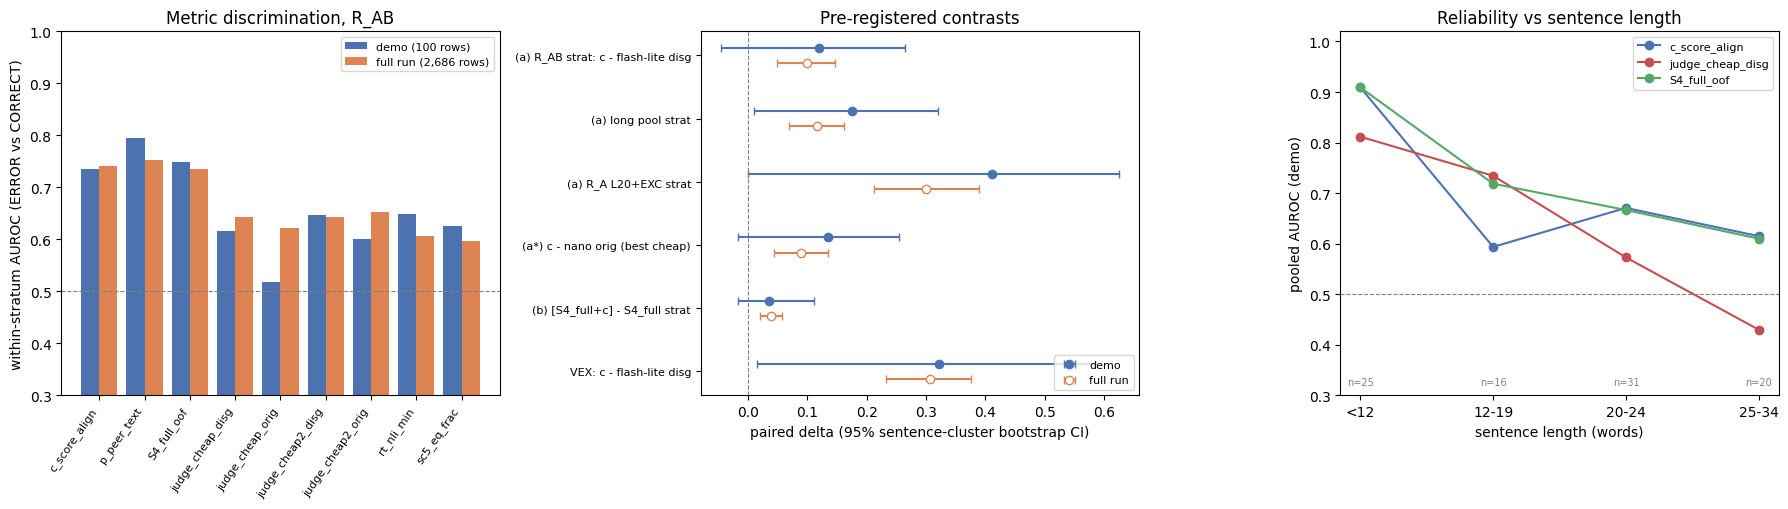

In [16]:
KEY = ["c_score_align", "p_peer_text", "S4_full_oof", "judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg",
       "judge_cheap2_orig", "rt_nli_min", "sc5_eq_frac"]
tab = []
for m in KEY:
    d = A["metrics_R_AB"].get(m, {})
    r = REF["auroc_R_AB"][m]
    tab.append({"metric": m, "demo pooled": d.get("auroc"),
                "demo pooled CI": f"[{d['ci'][0]:.3f}, {d['ci'][1]:.3f}]" if d.get("ci") else "",
                "demo strat": d.get("strat", {}).get("auroc"), "full pooled": r["pooled"], "full strat": r["strat"],
                "demo recall@FA0.10": d.get("at_FA0.10_E", {}).get("recall"),
                "$ / item": f"{cost_item[m]:.1e}" if cost_item.get(m) else "sum of parts"})
df = pd.DataFrame(tab).set_index("metric")
pd.set_option("display.width", 200)
print(df.round(3).to_string())

# verdict comparison
rows_v = []
fullc = REF["verdict"]["criteria"]
for c in ("a", "b", "d", "VEX", "M3"):
    dv = A["verdict"]["criteria"][c]
    rows_v.append({"criterion": c, "demo status": dv["status"], "full-run status": fullc[c]["status"]})
print()
print(pd.DataFrame(rows_v).set_index("criterion").to_string())

fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))
# (1) strat AUROC demo vs full
x = np.arange(len(KEY))
ax[0].bar(x - 0.2, [t["demo strat"] or np.nan for t in tab], 0.4, label="demo (100 rows)", color="#4C72B0")
ax[0].bar(x + 0.2, [t["full strat"] for t in tab], 0.4, label="full run (2,686 rows)", color="#DD8452")
ax[0].axhline(0.5, color="grey", lw=0.8, ls="--")
ax[0].set_xticks(x)
ax[0].set_xticklabels(KEY, rotation=55, ha="right", fontsize=8)
ax[0].set_ylabel("within-stratum AUROC (ERROR vs CORRECT)")
ax[0].set_ylim(0.3, 1.0)
ax[0].set_title("Metric discrimination, R_AB")
ax[0].legend(fontsize=8)
# (2) forest plot of the pre-registered deltas
fv = REF["verdict"]["criteria"]
forest = [("(a) R_AB strat: c - flash-lite disg", A["criterion_a"]["judge_cheap_disg"]["R_AB_strat"], fv["a"]["R_AB_strat"]),
          ("(a) long pool strat", A["criterion_a"]["judge_cheap_disg"]["long_strat"], fv["a"]["long_strat"]),
          ("(a) R_A L20+EXC strat", A["criterion_a"]["judge_cheap_disg"]["R_A_L20EXC"], fv["a"]["R_A_L20EXC"]),
          ("(a*) c - nano orig (best cheap)", A["criterion_a"]["judge_cheap2_orig"]["R_AB_strat"],
           REF["verdict"]["robustness_BEST_API_CHEAP"]["R_AB_strat"]),
          ("(b) [S4_full+c] - S4_full strat", A["b_s4"]["criterion_b"]["strat"], fv["b"]["strat"]),
          ("VEX: c - flash-lite disg", A["c_vex"]["vex_rule"], fv["VEX"])]
# (M3 is a log-odds slope difference, not a delta AUROC: it is reported in the verdict table above, not on this axis)
for i, (name, dm, fr) in enumerate(forest):
    yv = len(forest) - 1 - i
    if dm.get("delta") is not None and dm.get("ci") and dm["ci"][0] is not None:
        ax[1].errorbar(dm["delta"], yv + 0.12, xerr=[[dm["delta"] - dm["ci"][0]], [dm["ci"][1] - dm["delta"]]], fmt="o",
                       color="#4C72B0", capsize=3, label="demo" if i == 0 else None)
    ax[1].errorbar(fr["delta"], yv - 0.12, xerr=[[fr["delta"] - fr["ci"][0]], [fr["ci"][1] - fr["delta"]]], fmt="o",
                   mfc="white", color="#DD8452", capsize=3, label="full run" if i == 0 else None)
ax[1].axvline(0, color="grey", lw=0.8, ls="--")
ax[1].set_yticks(range(len(forest)))
ax[1].set_yticklabels([f[0] for f in forest][::-1], fontsize=8)
ax[1].set_xlabel("paired delta (95% sentence-cluster bootstrap CI)")
ax[1].set_title("Pre-registered contrasts")
ax[1].legend(fontsize=8, loc="lower right")
# (3) complexity curve by word count
wb = A["f_complexity"]["words"]
labs = [l for l in wb if wb[l]["metrics"]]
for m, col in (("c_score_align", "#4C72B0"), ("judge_cheap_disg", "#C44E52"), ("S4_full_oof", "#55A868")):
    ax[2].plot(labs, [wb[l]["metrics"][m].get("auroc", np.nan) for l in labs], "o-", color=col, label=m)
for j, l in enumerate(labs):
    ax[2].annotate(f"n={wb[l]['n']}", (j, 0.32), ha="center", fontsize=7, color="grey")
ax[2].axhline(0.5, color="grey", lw=0.8, ls="--")
ax[2].set_ylim(0.3, 1.02)
ax[2].set_xlabel("sentence length (words)")
ax[2].set_ylabel("pooled AUROC (demo)")
ax[2].set_title("Reliability vs sentence length")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()